In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

# Padding
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen = max_len)
x_test  = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train[0])
print(y_train[0])

[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113  103   32   15   16
 5345 

In [ ]:
# def build_model(layer_type):
#     model = keras.Sequential([
#         layers.Embedding(vocab_size, 128, input_length=max_len),

#         layer_type(64),

#         layers.Dense(1, activation='sigmoid')
#     ])

#     model.compile(
#         optimizer='adam',
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )
#     return model


def build_model(layer_type):
  model = keras.Sequential([
      layers.Embedding(vocab_size, 128),
      layers.SpatialDropout1D(0.2),
      layer_type(32, dropout= 0.2, recurrent_dropout = 0.2),
      layers.Dense(1, activation = 'sigmoid')
  ])

  model.compile(
      optimizer = 'adam',
      loss = 'binary_crossentropy',
      metrics = ['accuracy']
  )

  return model


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 2,
    restore_best_weights = True
)

In [ ]:
rnn_model = build_model(layers.SimpleRNN)

history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
    # callbacks=[early_stop]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 154ms/step - accuracy: 0.5149 - loss: 0.7111 - val_accuracy: 0.5356 - val_loss: 0.6856
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.5574 - loss: 0.6824 - val_accuracy: 0.5752 - val_loss: 0.6703
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.5828 - loss: 0.6672 - val_accuracy: 0.5848 - val_loss: 0.6591
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 151ms/step - accuracy: 0.6105 - loss: 0.6506 - val_accuracy: 0.5864 - val_loss: 0.6550
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.6389 - loss: 0.6285 - val_accuracy: 0.6356 - val_loss: 0.6310
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.6759 - loss: 0.5917 - val_accuracy: 0.6596 - val_loss: 0.5990
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.7214 - loss: 0.5448 - val_accuracy: 0.6822 - val_loss: 0.5836
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.7400 - loss: 0

In [ ]:
lstm_model = build_model(layers.LSTM)

history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
    # callbacks=[early_stop]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 379ms/step - accuracy: 0.7365 - loss: 0.5279 - val_accuracy: 0.8036 - val_loss: 0.4327
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 390ms/step - accuracy: 0.8378 - loss: 0.3798 - val_accuracy: 0.8346 - val_loss: 0.3749
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 373ms/step - accuracy: 0.8773 - loss: 0.3010 - val_accuracy: 0.8528 - val_loss: 0.3542
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 379ms/step - accuracy: 0.9014 - loss: 0.2542 - val_accuracy: 0.8550 - val_loss: 0.3667
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 363ms/step - accuracy: 0.9007 - loss: 0.2522 - val_accuracy: 0.8180 - val_loss: 0.4055
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 363ms/step - accuracy: 0.9212 - loss: 0.2053 - val_accuracy: 0.8506 - val_loss: 0.3936
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 372ms/step - accuracy: 0.9307 - loss: 0.1872 - val_accuracy: 0.8512 - val_loss: 0.4199
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 364ms/step - accuracy: 0.9162 - loss: 0

In [ ]:
gru_model = build_model(layers.GRU)

history_gru = gru_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
    # callbacks=[early_stop]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 347ms/step - accuracy: 0.6926 - loss: 0.5737 - val_accuracy: 0.7700 - val_loss: 0.4731
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 337ms/step - accuracy: 0.8284 - loss: 0.3977 - val_accuracy: 0.8022 - val_loss: 0.4276
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 339ms/step - accuracy: 0.8562 - loss: 0.3421 - val_accuracy: 0.7870 - val_loss: 0.4595
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 336ms/step - accuracy: 0.8802 - loss: 0.2928 - val_accuracy: 0.8124 - val_loss: 0.4179
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 339ms/step - accuracy: 0.9004 - loss: 0.2534 - val_accuracy: 0.8230 - val_loss: 0.4158
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 340ms/step - accuracy: 0.9183 - loss: 0.2141 - val_accuracy: 0.8170 - val_loss: 0.4500
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 336ms/step - accuracy: 0.9326 - loss: 0.1828 - val_accuracy: 0.8244 - val_loss: 0.4666
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 337ms/step - accuracy: 0.9452 - loss: 0

In [ ]:
print("RNN Accuracy:", history_rnn.history['val_accuracy'][-1])
print("LSTM Accuracy:", history_lstm.history['val_accuracy'][-1])
print("GRU Accuracy:", history_gru.history['val_accuracy'][-1])

RNN Accuracy: 0.7250000238418579
LSTM Accuracy: 0.8429999947547913
GRU Accuracy: 0.8245999813079834


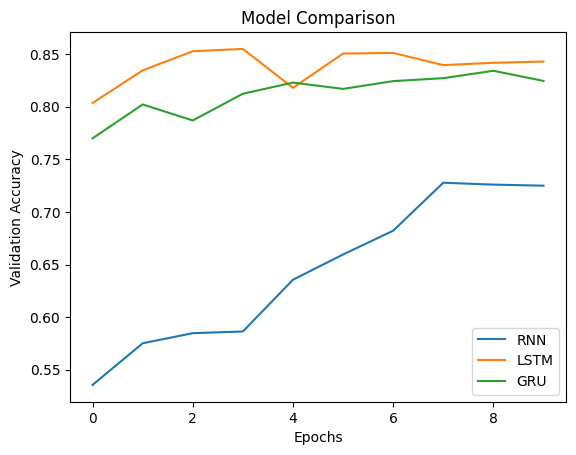

In [ ]:
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()